In [1]:
import sys
sys.path.append(r"D:\Train_thử\fairchem-tio2-s2ef")

from ocpmodels.preprocessing import AtomsToGraphs
from ocpmodels.datasets import SinglePointLmdbDataset, TrajectoryLmdbDataset, OC22LmdbDataset, LmdbDataset
import ase.io
from ase.build import bulk
from ase.build import fcc100, add_adsorbate, molecule
from ase.constraints import FixAtoms
from ase.calculators.emt import EMT
from ase.optimize import BFGS
import matplotlib.pyplot as plt
import lmdb
import pickle
from tqdm import tqdm
import torch
import os
from ocpmodels.common.relaxation.ase_utils import OCPCalculator

## Create TiO2 rutile slab

In [4]:
from ase import Atoms
import numpy as np

# Create TiO2 rutile structure manually
# Rutile TiO2 has tetragonal structure with Ti and O atoms

# Lattice parameters for rutile TiO2
a = 4.594  # Å
c = 2.959  # Å
u = 0.305  # internal parameter

# Define fractional positions
ti_positions = np.array([
    [0.0, 0.0, 0.0],      # Ti1
    [0.5, 0.5, 0.5]       # Ti2
])

o_positions = np.array([
    [u, u, 0.0],           # O1
    [1-u, 1-u, 0.0],       # O2
    [0.5+u, 0.5-u, 0.5],   # O3
    [0.5-u, 0.5+u, 0.5]    # O4
])

# Combine all positions (fractional coordinates)
all_positions = np.vstack([ti_positions, o_positions])

# Create lattice vectors
lattice_vectors = np.array([
    [a, 0.0, 0.0],
    [0.0, a, 0.0],
    [0.0, 0.0, c]
])

# Convert fractional to Cartesian coordinates
all_positions_cartesian = all_positions @ lattice_vectors

# Define atomic numbers (22 for Ti, 8 for O)
atomic_numbers = [22, 22, 8, 8, 8, 8]

# Create the Atoms object
tio2_rutile = Atoms(
    numbers=atomic_numbers,
    positions=all_positions_cartesian,  # Cartesian coordinates
    cell=lattice_vectors,
    pbc=True
)

print(f"Rutile TiO2 unit cell created")
print(f"Formula: {tio2_rutile.get_chemical_formula()}")
print(f"Number of atoms: {len(tio2_rutile)}")
print(f"Lattice parameters: a={a} Å, c={c} Å")
print(f"Elements: {tio2_rutile.get_chemical_symbols()}")

Rutile TiO2 unit cell created
Formula: O4Ti2
Number of atoms: 6
Lattice parameters: a=4.594 Å, c=2.959 Å
Elements: ['Ti', 'Ti', 'O', 'O', 'O', 'O']


## Visualize slab

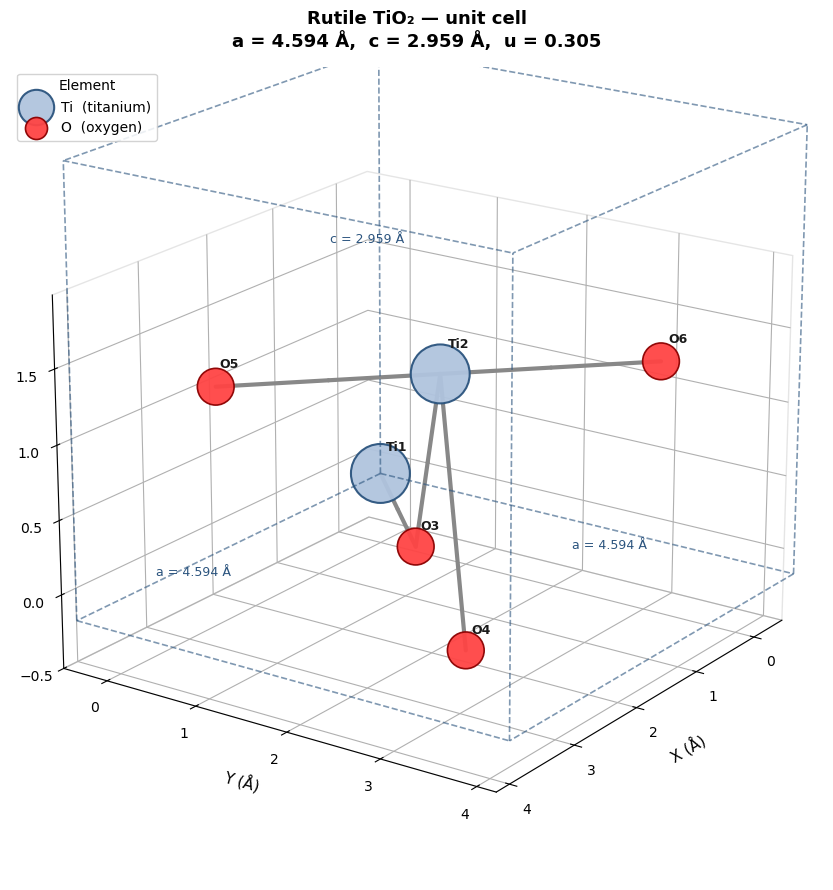

Saved → tio2_unit_cell.png


In [ ]:
from ase import Atoms
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from itertools import combinations

# ── Build structure ───────────────────────────────────────────────
a, c, u = 4.594, 2.959, 0.305

ti_positions = np.array([[0.0, 0.0, 0.0], [0.5, 0.5, 0.5]])
o_positions  = np.array([[u, u, 0.0], [1-u, 1-u, 0.0],
                          [0.5+u, 0.5-u, 0.5], [0.5-u, 0.5+u, 0.5]])

all_positions   = np.vstack([ti_positions, o_positions])
lattice_vectors = np.array([[a, 0, 0], [0, a, 0], [0, 0, c]])
cart            = all_positions @ lattice_vectors

tio2_rutile = Atoms(
    numbers   = [22, 22, 8, 8, 8, 8],
    positions = cart,
    cell      = lattice_vectors,
    pbc       = True
)

positions = tio2_rutile.get_positions()
symbols   = tio2_rutile.get_chemical_symbols()
numbers   = tio2_rutile.get_atomic_numbers()

# ── Bond detection ────────────────────────────────────────────────
def get_bonds(positions, symbols, cutoff=2.3):
    """Return list of (i, j) index pairs within cutoff distance."""
    bonds = []
    n = len(positions)
    for i in range(n):
        for j in range(i+1, n):
            if symbols[i] != symbols[j]:   # only Ti-O bonds
                dist = np.linalg.norm(positions[i] - positions[j])
                if dist < cutoff:
                    bonds.append((i, j))
    return bonds

bonds = get_bonds(positions, symbols, cutoff=2.3)

# ── Figure setup ─────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 9), facecolor="white")
ax  = fig.add_subplot(111, projection="3d", facecolor="white")

# ── Draw bonds first (under atoms) ───────────────────────────────
for i, j in bonds:
    p1, p2 = positions[i], positions[j]
    mid    = (p1 + p2) / 2
    # Draw two half-bonds with each atom's color for clarity
    ax.plot([p1[0], mid[0]], [p1[1], mid[1]], [p1[2], mid[2]],
            color="#888888", linewidth=3.0, zorder=2, solid_capstyle="round")
    ax.plot([mid[0], p2[0]], [mid[1], p2[1]], [mid[2], p2[2]],
            color="#888888", linewidth=3.0, zorder=2, solid_capstyle="round")

# ── Draw atoms ────────────────────────────────────────────────────
STYLE = {
    "Ti": {"color": "#B0C4DE", "size": 1800, "edgecolor": "#2B547E",
           "linewidth": 1.5, "label": "Ti  (titanium)"},
    "O":  {"color": "#FF4444", "size": 700,  "edgecolor": "#8B0000",
           "linewidth": 1.2, "label": "O  (oxygen)"},
}

for sym, style in STYLE.items():
    idx = [i for i, s in enumerate(symbols) if s == sym]
    pos = positions[idx]
    ax.scatter(
        pos[:,0], pos[:,1], pos[:,2],
        c           = style["color"],
        s           = style["size"],
        label       = style["label"],
        edgecolors  = style["edgecolor"],
        linewidths  = style["linewidth"],
        depthshade  = True,
        zorder      = 5,
        alpha       = 0.95,
    )

# ── Atom labels ───────────────────────────────────────────────────
label_offset = {"Ti": 0.25, "O": 0.18}
for i, (sym, pos) in enumerate(zip(symbols, positions)):
    off = label_offset[sym]
    ax.text(pos[0]+off, pos[1]+off, pos[2]+off,
            f"{sym}{i+1}",
            fontsize=9, fontweight="bold",
            color="#1a1a1a", zorder=10)

# ── Unit cell box ─────────────────────────────────────────────────
def draw_box(ax, cell):
    corners = np.array([[0,0,0],[1,0,0],[0,1,0],[0,0,1],
                         [1,1,0],[1,0,1],[0,1,1],[1,1,1]])
    verts = corners @ cell
    edges = [(0,1),(0,2),(0,3),(1,4),(1,5),(2,4),
             (2,6),(3,5),(3,6),(4,7),(5,7),(6,7)]
    segs = [(verts[i], verts[j]) for i, j in edges]
    lc = Line3DCollection(segs, colors="#2B547E",
                          linewidths=1.2, linestyles="--", alpha=0.6)
    ax.add_collection3d(lc)

draw_box(ax, lattice_vectors)

# ── Axis labels ───────────────────────────────────────────────────
ax.set_xlabel("X (Å)", fontsize=11, labelpad=8)
ax.set_ylabel("Y (Å)", fontsize=11, labelpad=8)
ax.set_zlabel("Z (Å)", fontsize=11, labelpad=8)

# ── Padding around structure ──────────────────────────────────────
pad = 0.5
ax.set_xlim(positions[:,0].min()-pad, positions[:,0].max()+pad)
ax.set_ylim(positions[:,1].min()-pad, positions[:,1].max()+pad)
ax.set_zlim(positions[:,2].min()-pad, positions[:,2].max()+pad)

# ── Grid and pane style ───────────────────────────────────────────
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("#cccccc")
ax.yaxis.pane.set_edgecolor("#cccccc")
ax.zaxis.pane.set_edgecolor("#cccccc")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.4)

# ── Viewing angle ─────────────────────────────────────────────────
ax.view_init(elev=20, azim=35)

# ── Title + legend ────────────────────────────────────────────────
ax.set_title(
    "Rutile TiO₂ — unit cell\n"
    "a = 4.594 Å,  c = 2.959 Å,  u = 0.305",
    fontsize=13, fontweight="bold", pad=14
)

legend = ax.legend(
    title="Element", title_fontsize=10,
    fontsize=10, loc="upper left",
    framealpha=0.85, edgecolor="#cccccc",
    markerscale=0.6,
)

# ── Lattice parameter annotations ────────────────────────────────
ax.text(a/2, -0.5, -0.3, f"a = {a} Å",
        fontsize=9, color="#2B547E", ha="center")
ax.text(-0.5, a/2, -0.3, f"a = {a} Å",
        fontsize=9, color="#2B547E", ha="center")
ax.text(-0.5, -0.5, c/2, f"c = {c} Å",
        fontsize=9, color="#2B547E", ha="center")

plt.tight_layout()
plt.savefig("tio2_unit_cell.png", dpi=180, bbox_inches="tight",
            facecolor="white")
plt.show()
#print("Saved → tio2_unit_cell.png")

## Surface Cleaving

In [6]:
from ase.build import surface
from ase.io import write

# Build slab from bulk
# miller_index matches your OC22 data: (1,1,1) or (1,1,-1)
slab = surface(
    lattice      = tio2_rutile,  # ← Fixed: use tio2_rutile instead of tio2_bulk
    indices      = (1, 1, 1),    # change to (1,1,-1) for second surface
    layers       = 4,            # 4 layers of TiO2 = enough thickness
    vacuum       = 15.0          # 15 Angstrom vacuum on top
)

print(f"Slab atoms: {len(slab)}")
print(f"Cell dimensions: {slab.cell}")
print(f"Vacuum layer: check z-direction spacing")

# Save to file to visualize
write("tio2_slab_111.traj", slab)
write("tio2_slab_111.xyz",  slab)   # open with VESTA or Avogadro

Slab atoms: 24
Cell dimensions: Cell([[5.464477742657572, 0.0, 0.0], [1.6022905412625577, 5.22428770469052, 0.0], [0.0, 0.0, 37.89693205953968]])
Vacuum layer: check z-direction spacing


## Slab Quality Control

In [7]:
import numpy as np

positions = slab.get_positions()
z_coords  = positions[:, 2]
cell      = slab.get_cell()

z_min        = z_coords.min()
z_max        = z_coords.max()
z_cell       = cell[2][2]
slab_thickness = z_max - z_min
vacuum_actual  = z_cell - z_max

print(f"Slab thickness:  {slab_thickness:.3f} Å")
print(f"Vacuum layer:    {vacuum_actual:.3f} Å")
print(f"Total z cell:    {z_cell:.3f} Å")
print()

# Check vacuum is sufficient
if vacuum_actual >= 10:
    print(f"✅ Vacuum OK: {vacuum_actual:.1f} Å")
else:
    print(f"❌ Vacuum too small: {vacuum_actual:.1f} Å — increase vacuum parameter")

# Check slab thickness is reasonable
if slab_thickness <= 15:
    print(f"✅ Slab thickness OK: {slab_thickness:.1f} Å")
else:
    print(f"⚠️ Slab unusually thick: {slab_thickness:.1f} Å — consider reducing layers to 3")

# Print z positions of all atoms to see layer distribution
print(f"\nAtom z-positions (to check layer structure):")
symbols = slab.get_chemical_symbols()
for i, (sym, z) in enumerate(zip(symbols, z_coords)):
    print(f"  Atom {i:>2} {sym}: z = {z:.3f} Å")

Slab thickness:  7.897 Å
Vacuum layer:    15.000 Å
Total z cell:    37.897 Å

✅ Vacuum OK: 15.0 Å
✅ Slab thickness OK: 7.9 Å

Atom z-positions (to check layer structure):
  Atom  0 Ti: z = 15.000 Å
  Atom  1 Ti: z = 16.094 Å
  Atom  2 O: z = 16.334 Å
  Atom  3 O: z = 15.853 Å
  Atom  4 O: z = 16.094 Å
  Atom  5 O: z = 16.094 Å
  Atom  6 Ti: z = 17.188 Å
  Atom  7 Ti: z = 18.281 Å
  Atom  8 O: z = 18.522 Å
  Atom  9 O: z = 18.041 Å
  Atom 10 O: z = 18.281 Å
  Atom 11 O: z = 18.281 Å
  Atom 12 Ti: z = 19.375 Å
  Atom 13 Ti: z = 20.469 Å
  Atom 14 O: z = 20.709 Å
  Atom 15 O: z = 20.228 Å
  Atom 16 O: z = 20.469 Å
  Atom 17 O: z = 20.469 Å
  Atom 18 Ti: z = 21.563 Å
  Atom 19 Ti: z = 22.656 Å
  Atom 20 O: z = 22.897 Å
  Atom 21 O: z = 22.416 Å
  Atom 22 O: z = 22.656 Å
  Atom 23 O: z = 22.656 Å


## Supercell Construction

In [8]:
# Repeat the slab 3x3 in x and y directions
# 1 in z direction = do NOT repeat vertically (keep vacuum intact)
supercell = slab.repeat([3, 3, 1])

print(f"Supercell atoms:      {len(supercell)}")
print(f"Supercell dimensions: {supercell.cell}")

# Save supercell
write("tio2_supercell_3x3_111.traj", supercell)
write("tio2_supercell_3x3_111.xyz",  supercell)

Supercell atoms:      216
Supercell dimensions: Cell([[16.393433227972718, 0.0, 0.0], [4.806871623787673, 15.672863114071559, 0.0], [0.0, 0.0, 37.89693205953968]])


## Slab Final Quality Check

In [9]:
import numpy as np
from ase.data import chemical_symbols

positions = supercell.get_positions()
symbols   = supercell.get_chemical_symbols()
cell      = supercell.get_cell()

# Check vacuum size
z_coords    = positions[:, 2]
z_max       = z_coords.max()
z_cell      = cell[2][2]
vacuum_size = z_cell - z_max

print(f"Total atoms in supercell: {len(supercell)}")
print(f"Cell size (x, y, z): "
      f"{cell[0][0]:.2f} x {cell[1][1]:.2f} x {cell[2][2]:.2f} Angstrom")
print(f"Slab thickness:  {z_max - z_coords.min():.2f} Angstrom")
print(f"Vacuum layer:    {vacuum_size:.2f} Angstrom")

# Count elements
ti_count = symbols.count("Ti")
o_count  = symbols.count("O")
print(f"Ti atoms: {ti_count}")
print(f"O  atoms: {o_count}")

# Verify vacuum is sufficient
if vacuum_size >= 10:
    print(f"Vacuum OK ({vacuum_size:.1f} Angstrom >= 10 Angstrom)")
else:
    print(f"WARNING: Vacuum too small ({vacuum_size:.1f} Angstrom)")

Total atoms in supercell: 216
Cell size (x, y, z): 16.39 x 15.67 x 37.90 Angstrom
Slab thickness:  7.90 Angstrom
Vacuum layer:    15.00 Angstrom
Ti atoms: 72
O  atoms: 144
Vacuum OK (15.0 Angstrom >= 10 Angstrom)


## Fix Bottom Layer

In [10]:
from ase.constraints import FixAtoms

# Freeze the bottom 2 layers so only surface atoms relax
# Bottom atoms = lowest z positions
z_coords   = supercell.get_positions()[:, 2]
z_min      = z_coords.min()
z_threshold = z_min + 4.0    # freeze atoms in bottom ~4 Angstrom

fixed_indices = [
    i for i, z in enumerate(z_coords)
    if z < z_threshold
]

constraint = FixAtoms(indices=fixed_indices)
supercell.set_constraint(constraint)

print(f"Fixed (frozen) atoms:  {len(fixed_indices)}")
print(f"Free (relaxing) atoms: {len(supercell) - len(fixed_indices)}")

# Save final slab ready for glucose placement
write("tio2_supercell_3x3_final.traj", supercell)
write("tio2_supercell_3x3_final.xyz",  supercell)

Fixed (frozen) atoms:  108
Free (relaxing) atoms: 108


## Rebuild slab and place fragment on Ti5c

In [11]:
# ══════════════════════════════════════════════════════════════════
# CELL 1: REBUILD SLAB — same as before, no glucose needed
# ══════════════════════════════════════════════════════════════════
import numpy as np
import os
from ase import Atoms
from ase.io import read, write
from ase.constraints import FixAtoms
from scipy.spatial.distance import cdist

# ── Step 1: Rebuild TiO2 rutile unit cell ─────────────────────────
a, c, u = 4.594, 2.959, 0.305

ti_pos = np.array([[0.0, 0.0, 0.0], [0.5, 0.5, 0.5]])
o_pos  = np.array([[u, u, 0.0], [1-u, 1-u, 0.0],
                   [0.5+u, 0.5-u, 0.5], [0.5-u, 0.5+u, 0.5]])
lattice = np.array([[a, 0, 0], [0, a, 0], [0, 0, c]])
cart    = np.vstack([ti_pos, o_pos]) @ lattice

tio2_rutile = Atoms(numbers=[22,22,8,8,8,8],
                    positions=cart, cell=lattice, pbc=True)

# ── Step 2: Build slab → supercell ────────────────────────────────
from ase.build import surface

slab = surface(tio2_rutile, indices=(1,1,1), layers=4, vacuum=15.0)
slab = slab.repeat([3, 3, 1])

# ── Step 3: Assign tags ───────────────────────────────────────────
positions = slab.get_positions()
numbers   = slab.get_atomic_numbers()
z_coords  = positions[:, 2]
z_rounded = np.round(z_coords, 1)
unique_z  = np.sort(np.unique(z_rounded))[::-1]
top_2_z   = set(unique_z[:2])
tags = np.array([1 if round(z,1) in top_2_z else 0 for z in z_coords])
slab.set_tags(tags)

# ── Freeze bulk atoms ─────────────────────────────────────────────
fixed_indices = [i for i, t in enumerate(tags) if t == 0]
slab.set_constraint(FixAtoms(indices=fixed_indices))
slab.center(vacuum=13.0, axis=2)
slab.set_pbc(True)

# ── Step 4: Find Ti5c sites ───────────────────────────────────────
def find_ti5c(slab, cutoff=3.0):
    pos    = slab.get_positions()
    nums   = slab.get_atomic_numbers()
    tags   = slab.get_tags()
    dists  = cdist(pos, pos)
    o_mask = nums == 8
    ti5c   = []
    for i in np.where((nums == 22) & (tags == 1))[0]:
        n_o = np.sum((dists[i] <= cutoff) & (dists[i] > 0) & o_mask)
        if n_o == 5:
            ti5c.append({"idx": i, "pos": pos[i].copy(), "z": pos[i,2]})
    return ti5c

ti5c_list    = find_ti5c(slab, cutoff=3.0)
best_ti5c    = max(ti5c_list, key=lambda x: x["z"])
all_ti5c_pos = np.array([t["pos"] for t in ti5c_list])

# ── Step 5: Build glucose fragments ──────────────────────────────
# Replaces glucose molecule — each fragment is a small Atoms object
import math

FRAGMENTS = {
    # name : (Atoms object,  label,                  description)
    "C": (
        Atoms("C", positions=[[0, 0, 0]]),
        "C-C backbone",
        "How strongly TiO2 holds carbon fragments"
    ),
    "OH": (
        Atoms("OH", positions=[[0, 0, 0], [0, 0, 0.97]]),
        "-OH hydroxyl group",
        "How TiO2 handles oxygen and hydrogen from glucose"
    ),
    "CHO": (
        Atoms('CHO', positions=[
        [0.0, 0.0, 0.0],
        [1.21, 0.0, 0.0],
        [-0.55, 0.95, 0.0]]),
        "Aldehyde -CHO group",
        "How TiO2 binds CO intermediates"
    ),
    "CO2": (
        Atoms("OCO", positions=[[0, 0, -1.16], [0, 0, 0], [0, 0, 1.16]]),
        "CO2 release (CO + O)",
        "Energy cost of desorption step"
    ),
    "H2O": (
        Atoms(
            "HOH",
            positions=[
                [-0.96*math.sin(math.radians(52.25)), 0,
                  0.96*math.cos(math.radians(52.25))],
                [0, 0, 0],
                [ 0.96*math.sin(math.radians(52.25)), 0,
                  0.96*math.cos(math.radians(52.25))],
            ]
        ),
        "H2O release (H + O)",
        "Energy cost of water formation"
    ),
}

# ── Step 6: Place each fragment above best Ti5c ───────────────────
height = 2.5   # Å above Ti5c — same as original glucose placement

def place_fragment(slab, frag_atoms, ti5c_pos, height=2.5, rotation=0):
    frag = frag_atoms.copy()
    if rotation != 0:
        frag.rotate(rotation, "z", center="COM")

    # Orient lowest atom toward surface
    pos      = frag.get_positions()
    lowest_i = np.argmin(pos[:, 2])
    frag.translate([0, 0, -pos[lowest_i, 2]])

    # Place COM above Ti5c at given height
    com = frag.get_center_of_mass()
    frag.translate([
        ti5c_pos[0] - com[0],
        ti5c_pos[1] - com[1],
        ti5c_pos[2] + height - com[2]
    ])

    # Tag fragment atoms as adsorbate (tag=2)
    frag.set_tags([2] * len(frag))
    return slab + frag

# Build one adslab per fragment (rotation=0, best Ti5c)
adslabs = {}
for frag_name, (frag_atoms, label, description) in FRAGMENTS.items():
    system      = place_fragment(slab, frag_atoms,
                                 best_ti5c["pos"], height=height)
    system_tags = np.concatenate([tags, np.full(len(frag_atoms), 2)])
    system.set_tags(system_tags)
    adslabs[frag_name] = system

    print(f"Fragment {frag_name:<4} ready : {len(system):>3} atoms | "
          f"{label}")

print(f"\nSlab atoms       : {len(slab)}")
print(f"Ti5c sites found : {len(ti5c_list)}")
print(f"Best Ti5c        : atom({best_ti5c['idx']}) "
      f"at z={best_ti5c['z']:.3f} Å")
print(f"Height above Ti5c: {height} Å")
print(f"\nReady → attach OCPCalculator and run relaxation")

Fragment C    ready : 217 atoms | C-C backbone
Fragment OH   ready : 218 atoms | -OH hydroxyl group
Fragment CHO  ready : 219 atoms | Aldehyde -CHO group
Fragment CO2  ready : 219 atoms | CO2 release (CO + O)
Fragment H2O  ready : 219 atoms | H2O release (H + O)

Slab atoms       : 216
Ti5c sites found : 4
Best Ti5c        : atom(19) at z=20.656 Å
Height above Ti5c: 2.5 Å

Ready → attach OCPCalculator and run relaxation


## Fine-tuning Energy And Force Of Fragments Base On Time 

In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 2: ATTACH CALCULATOR AND RELAX ALL FRAGMENTS
# Same calc setup as original — only the loop is new
# ══════════════════════════════════════════════════════════════════
from ocpmodels.common.relaxation.ase_utils import OCPCalculator
from ase.optimize import LBFGS
from ase.io import read
from ase.io import extxyz
import pandas as pd

calc = OCPCalculator(
    config_yml = r"/content/fairchem-tio2-s2ef/configs/s2ef/all/gemnet/gemnet-dT.yml",
    checkpoint = r"/content/drive/MyDrive/abc/checkpoint.pt",
)

os.makedirs("data", exist_ok=True)
results = []

# ── Relax each fragment ───────────────────────────────────────────
for frag_name, system in adslabs.items():
    _, label, description = FRAGMENTS[frag_name]

    traj_path = f"data/tio2_{frag_name}_relax.traj"
    xyz_path  = f"data/tio2_{frag_name}_relax.extxyz"

    print(f"\n{'='*55}")
    print(f"Fragment : {frag_name}  ({label})")
    print(f"Atoms    : {len(system)}")
    print(f"{'='*55}")

    system.calc = calc

    dyn = LBFGS(system, trajectory=traj_path, maxstep=0.05)
    dyn.run(fmax=0.05, steps=500)

    # ── Read results ──────────────────────────────────────────────
    traj       = read(traj_path, ":")
    e_init     = traj[0].get_potential_energy()
    e_final    = traj[-1].get_potential_energy()
    fmax_init  = np.linalg.norm(traj[0].get_forces(),  axis=1).max()
    fmax_final = np.linalg.norm(traj[-1].get_forces(), axis=1).max()
    converged  = fmax_final <= 0.05

    print(f"Frames        : {len(traj)}")
    print(f"E_initial     : {e_init:.4f} eV")
    print(f"E_final       : {e_final:.4f} eV")
    print(f"fmax_initial  : {fmax_init:.4f} eV/Å")
    print(f"fmax_final    : {fmax_final:.4f} eV/Å")
    print(f"Converged     : {'YES ✓' if converged else 'NO — increase steps'}")

    # ── Save extxyz ───────────────────────────────────────────────
    columns = ["symbols", "positions", "move_mask", "tags"]
    with open(xyz_path, "w") as f:
        extxyz.write_xyz(f, traj, columns=columns)

    results.append({
        "fragment":      frag_name,
        "label":         label,
        "description":   description,
        "n_atoms":       len(system),
        "n_frames":      len(traj),
        "E_initial (eV)":round(e_init,  4),
        "E_final (eV)":  round(e_final, 4),
        "fmax_initial":  round(fmax_init,  4),
        "fmax_final":    round(fmax_final, 4),
        "converged":     converged,
        "traj_file":     traj_path,
        "xyz_file":      xyz_path,
    })

# ── Summary table ─────────────────────────────────────────────────
df = pd.DataFrame(results)
df.to_csv("data/fragment_relaxation_summary.csv", index=False)

print(f"\n{'='*55}")
print(f"ALL FRAGMENTS COMPLETE")
print(f"{'='*55}")
print(df[["fragment","label","E_final (eV)",
          "fmax_final","converged"]].to_string(index=False))
print(f"\nSaved → data/fragment_relaxation_summary.csv")

## View The Trajectory Of Fragments

Checking files:
  C    OK  D:\Train_thử\fairchem-tio2-s2ef\tio2_C_relax.traj
  OH   OK  D:\Train_thử\fairchem-tio2-s2ef\tio2_OH_relax.traj
  CHO  OK  D:\Train_thử\fairchem-tio2-s2ef\tio2_CHO_relax.traj
  CO2  OK  D:\Train_thử\fairchem-tio2-s2ef\tio2_CO2_relax.traj
  H2O  OK  D:\Train_thử\fairchem-tio2-s2ef\tio2_H2O_relax.traj


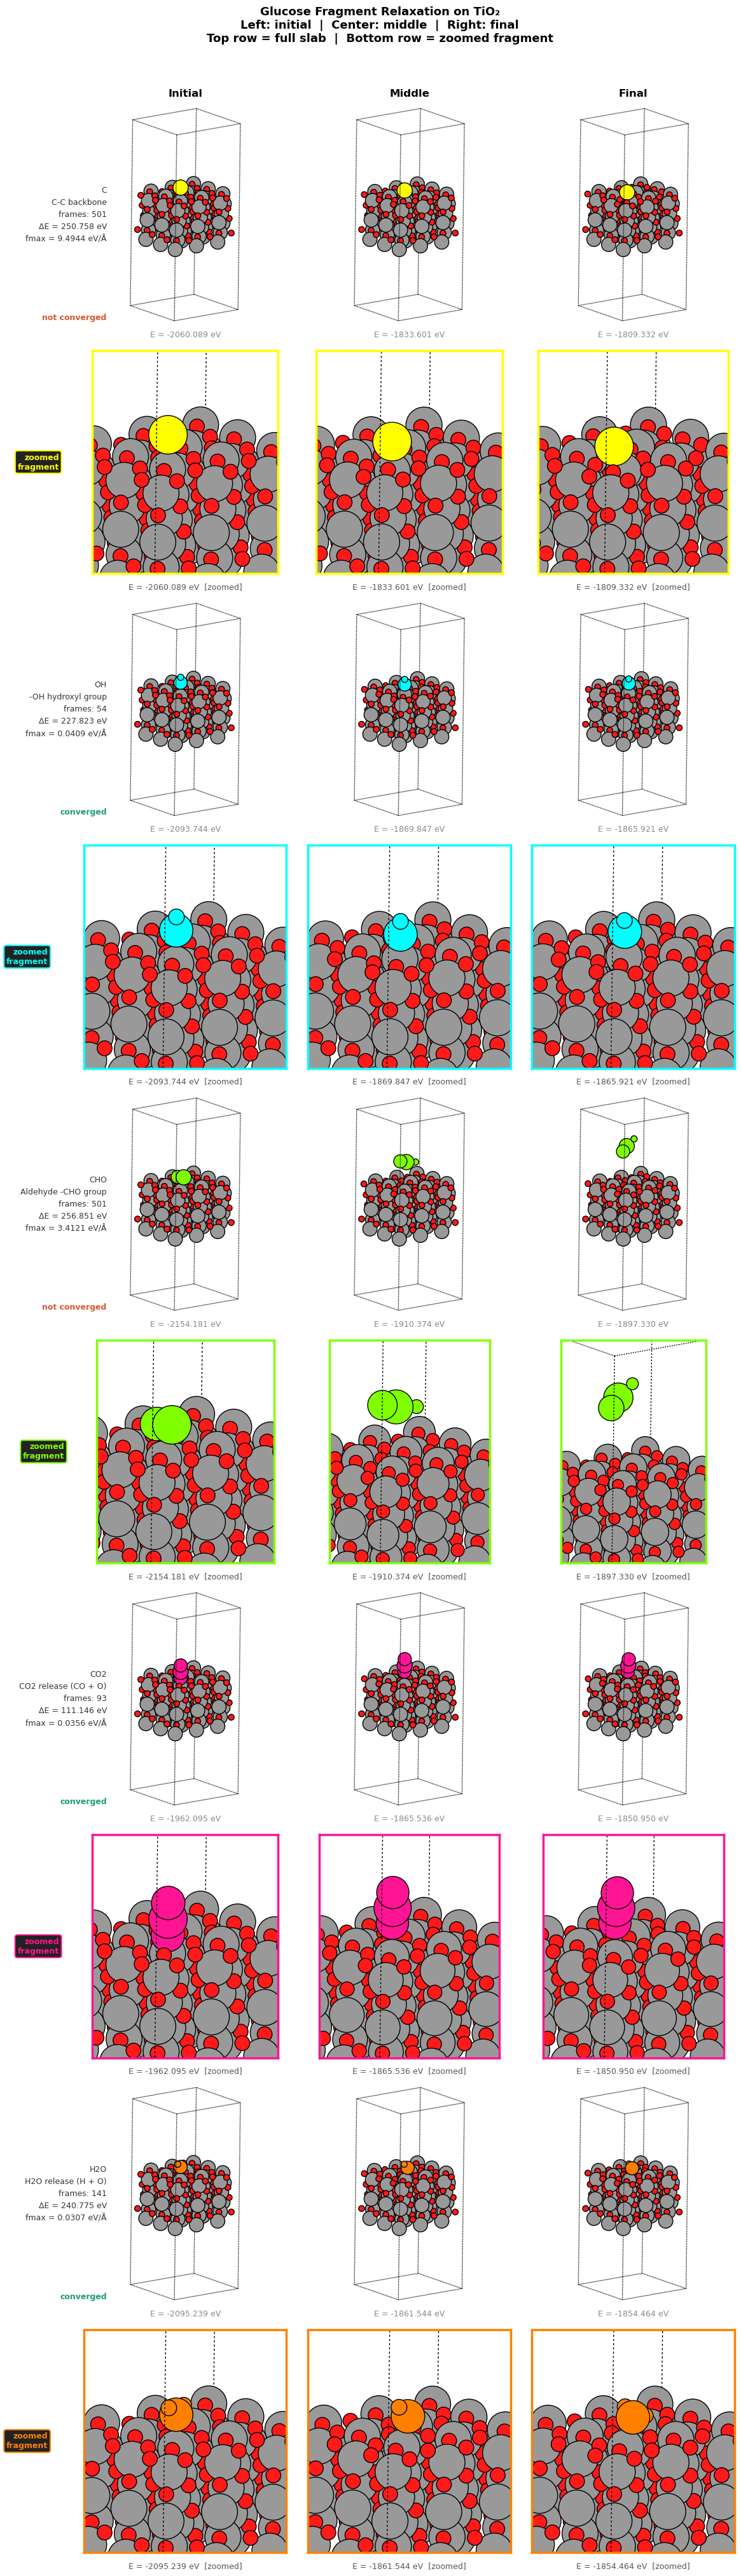

Saved → D:\Train_thử\fairchem-tio2-s2ef\fragment_trajectory_view.png


In [11]:
import ase
import ase.visualize.plot
import matplotlib.pyplot as plt
from ase.io import read
from ase.data import covalent_radii
import numpy as np
import os

# ── Files are in the project root ────────────────────────────────
DATA_DIR = r"D:\Train_thử\fairchem-tio2-s2ef"

FRAGMENT_TRAJS = {
    "C":   (os.path.join(DATA_DIR, "tio2_C_relax.traj"),   "C-C backbone",         False),
    "OH":  (os.path.join(DATA_DIR, "tio2_OH_relax.traj"),  "-OH hydroxyl group",   True),
    "CHO": (os.path.join(DATA_DIR, "tio2_CHO_relax.traj"), "Aldehyde -CHO group",  False),
    "CO2": (os.path.join(DATA_DIR, "tio2_CO2_relax.traj"), "CO2 release (CO + O)", True),
    "H2O": (os.path.join(DATA_DIR, "tio2_H2O_relax.traj"), "H2O release (H + O)",  True),
}

# ── Color settings ────────────────────────────────────────────────
COLOR_Ti = "#999999"    # gray
COLOR_O  = "#FF1A1A"    # red

FRAGMENT_COLORS = {
    "C":   "#FFFF00",   # neon yellow
    "OH":  "#00FFFF",   # cyan
    "CHO": "#80FF00",   # lime green
    "CO2": "#FF1493",   # magenta
    "H2O": "#FF8000",   # neon orange
}

SLAB_RADII_SCALE  = 0.8
FRAG_RADII_SCALE  = 1.8

# ── Zoom: how many Å around fragment atoms to show ────────────────
ZOOM_PADDING = 4.0    # increase for wider zoom, decrease for tighter


def get_colors_and_radii(atoms, frag_color_hex):
    """
    Returns:
      colors : list of hex color strings, one per atom
      radii  : np.array of display radii, one per atom
    Ti → gray, O → red, tag==2 → neon fragment color (enlarged)
    """
    tags  = atoms.get_tags()
    nums  = atoms.get_atomic_numbers()
    radii = np.array([covalent_radii[z] for z in nums], dtype=float)
    colors = []

    for i in range(len(atoms)):
        if tags[i] == 2:
            colors.append(frag_color_hex)
            radii[i] *= FRAG_RADII_SCALE
        elif nums[i] == 22:     # Ti
            colors.append(COLOR_Ti)
            radii[i] *= SLAB_RADII_SCALE
        elif nums[i] == 8:      # O
            colors.append(COLOR_O)
            radii[i] *= SLAB_RADII_SCALE
        else:
            colors.append("#CCCCCC")
            radii[i] *= SLAB_RADII_SCALE

    return colors, radii


def get_fragment_bbox_2d(ax):
    """
    After plot_atoms has drawn, find the bounding box of the
    fragment atoms (the enlarged ones) in display/axes coordinates,
    then convert to data coordinates for ax.set_xlim / ax.set_ylim.
    Returns (x0, x1, y0, y1) in data coords, or None if not found.
    """
    # plot_atoms draws circles as PathCollections or Circles
    # We look for the largest artists (fragment = biggest radii)
    all_artists = ax.get_children()
    circles = [a for a in all_artists
                if isinstance(a, plt.matplotlib.patches.Circle)]

    if not circles:
        return None

    # Sort by radius descending; fragment atoms have largest radius
    circles_sorted = sorted(circles, key=lambda c: c.radius, reverse=True)

    # The fragment atoms are the top few largest circles
    # Take the top 5 (safe upper bound even for CHO/H2O/CO2)
    frag_circles = circles_sorted[:5]

    xs = [c.center[0] for c in frag_circles]
    ys = [c.center[1] for c in frag_circles]
    rs = [c.radius     for c in frag_circles]

    x0 = min(x - r for x, r in zip(xs, rs)) - ZOOM_PADDING
    x1 = max(x + r for x, r in zip(xs, rs)) + ZOOM_PADDING
    y0 = min(y - r for y, r in zip(ys, rs)) - ZOOM_PADDING
    y1 = max(y + r for y, r in zip(ys, rs)) + ZOOM_PADDING

    return x0, x1, y0, y1


# ── Quick check ───────────────────────────────────────────────────
print("Checking files:")
for name, (path, label, _) in FRAGMENT_TRAJS.items():
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"  {name:<4} {status}  {path}")

rotation = "-75x, 45y, 10z"

# Each fragment → 2 rows: full view (row A) + zoomed view (row B)
n_frags  = len(FRAGMENT_TRAJS)
fig, axes = plt.subplots(
    nrows   = n_frags * 2,
    ncols   = 3,
    figsize = (12, 4 * n_frags * 2)
)

fig.suptitle(
    "Glucose Fragment Relaxation on TiO₂\n"
    "Left: initial  |  Center: middle  |  Right: final\n"
    "Top row = full slab  |  Bottom row = zoomed fragment",
    fontsize=13, fontweight="bold", y=1.01
)

for row_idx, (frag_name, (traj_path, label, converged)) in \
        enumerate(FRAGMENT_TRAJS.items()):

    traj      = read(traj_path, ":")
    n_frames  = len(traj)
    mid_frame = n_frames // 2

    e_init  = traj[0].get_potential_energy()
    e_final = traj[-1].get_potential_energy()
    fmax    = np.linalg.norm(traj[-1].get_forces(), axis=1).max()

    frag_color_hex = FRAGMENT_COLORS[frag_name]

    frame_map = {
        "Initial": traj[0],
        "Middle":  traj[mid_frame],
        "Final":   traj[-1],
    }

    full_row   = row_idx * 2       # full-slab row index
    zoom_row   = row_idx * 2 + 1   # zoomed row index

    for col_idx, (frame_label, atoms) in enumerate(frame_map.items()):

        colors, radii = get_colors_and_radii(atoms, frag_color_hex)

        # ── Full view ─────────────────────────────────────────────
        ax_full = axes[full_row, col_idx]
        ax_full.axis("off")
        ase.visualize.plot.plot_atoms(
            atoms, ax_full,
            colors=colors,
            radii=radii,
            rotation=rotation,
        )
        if row_idx == 0:
            ax_full.set_title(frame_label, fontsize=12,
                              fontweight="bold", pad=8)
        e = atoms.get_potential_energy()
        ax_full.text(0.5, -0.02, f"E = {e:.3f} eV",
                     transform=ax_full.transAxes,
                     ha="center", va="top", fontsize=9, color="#888888")

        # ── Zoomed view ───────────────────────────────────────────
        ax_zoom = axes[zoom_row, col_idx]
        ax_zoom.axis("off")
        ase.visualize.plot.plot_atoms(
            atoms, ax_zoom,
            colors=colors,
            radii=radii,
            rotation=rotation,
        )

        # Apply zoom around fragment atoms
        bbox = get_fragment_bbox_2d(ax_zoom)
        if bbox:
            x0, x1, y0, y1 = bbox
            ax_zoom.set_xlim(x0, x1)
            ax_zoom.set_ylim(y0, y1)
            ax_zoom.axis("on")
            ax_zoom.set_xticks([])
            ax_zoom.set_yticks([])
            # Colored border matching fragment
            for spine in ax_zoom.spines.values():
                spine.set_edgecolor(frag_color_hex)
                spine.set_linewidth(2.5)

        ax_zoom.text(0.5, -0.04, f"E = {e:.3f} eV  [zoomed]",
                     transform=ax_zoom.transAxes,
                     ha="center", va="top", fontsize=9, color="#555555")

    # ── Left-side labels for full row ─────────────────────────────
    status_color = "#1D9E75" if converged else "#D85A30"
    axes[full_row, 0].text(
        -0.18, 0.5,
        f"{frag_name}\n{label}\n"
        f"frames: {n_frames}\n"
        f"\u0394E = {e_final - e_init:.3f} eV\n"
        f"fmax = {fmax:.4f} eV/\u00c5",
        transform=axes[full_row, 0].transAxes,
        ha="right", va="center", fontsize=9, color="#333333",
        linespacing=1.6,
    )
    axes[full_row, 0].text(
        -0.18, 0.02,
        "converged" if converged else "not converged",
        transform=axes[full_row, 0].transAxes,
        ha="right", va="bottom", fontsize=9,
        fontweight="bold", color=status_color,
    )

    # ── Left-side label for zoom row ──────────────────────────────
    axes[zoom_row, 0].text(
        -0.18, 0.5, "zoomed\nfragment",
        transform=axes[zoom_row, 0].transAxes,
        ha="right", va="center", fontsize=9,
        color=frag_color_hex,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="#222222", edgecolor=frag_color_hex,
                  linewidth=1.5),
    )

plt.tight_layout()
out_path = os.path.join(DATA_DIR, "fragment_trajectory_view.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

Checking traj files:
  OH       ✓ OK  →  D:\Train_thử\fairchem-tio2-s2ef\N20_92_116_OH_relax.traj
  H2O      ✓ OK  →  D:\Train_thử\fairchem-tio2-s2ef\N20_44_92_116_H2O_relax.traj
  CHO      ✓ OK  →  D:\Train_thử\fairchem-tio2-s2ef\N20_116_OH_relax.traj
  CO2      ✗ MISSING  →  D:\Train_thử\fairchem-tio2-s2ef\N20_44_92_116_CO2_relax.traj
  O        ✗ MISSING  →  D:\Train_thử\fairchem-tio2-s2ef\N20_44_92_116_O_relax.traj
⚠ Skipping CO2 — file not found
⚠ Skipping O — file not found


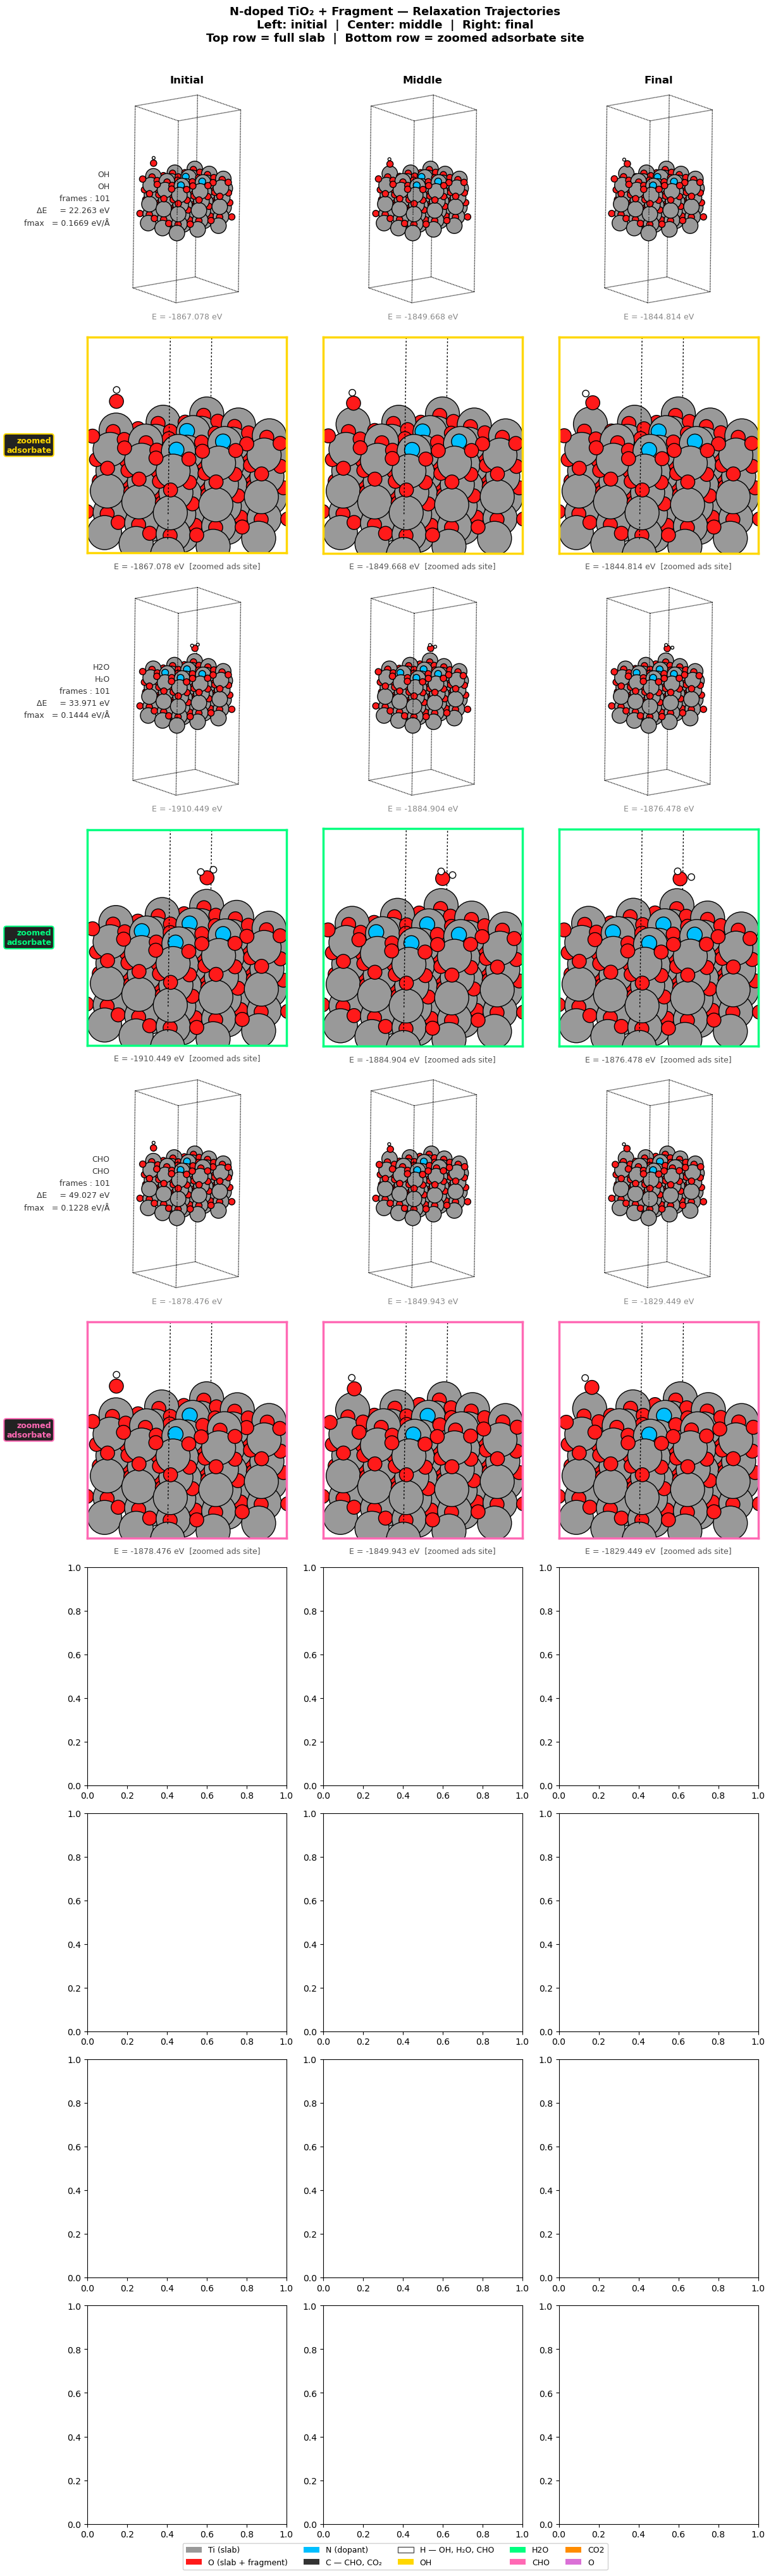


Saved → D:\Train_thử\fairchem-tio2-s2ef\ndoped_fragment_trajectory_view.png


In [7]:
import ase
import ase.visualize.plot
import matplotlib.pyplot as plt
from ase.io import read
from ase.data import covalent_radii
import numpy as np
import os

# ── Base directory ────────────────────────────────────────────────
BASE = r"D:\Train_thử\fairchem-tio2-s2ef"

# ══════════════════════════════════════════════════════════════════
#  ĐỔI CÁC FILE TRAJ CỦA BẠN VÀO ĐÂY
# ══════════════════════════════════════════════════════════════════
FRAGMENT_TRAJS = {
    "OH":  (r"D:\Train_thử\fairchem-tio2-s2ef\N20_92_116_OH_relax.traj",  "OH"),
    "H2O": (r"D:\Train_thử\fairchem-tio2-s2ef\N20_44_92_116_H2O_relax.traj", "H₂O"),
    "CHO": (r"D:\Train_thử\fairchem-tio2-s2ef\N20_116_OH_relax.traj", "CHO"),
    "CO2": (r"D:\Train_thử\fairchem-tio2-s2ef\N20_44_92_116_CO2_relax.traj", "CO₂"),
    "O":   (r"D:\Train_thử\fairchem-tio2-s2ef\N20_44_92_116_O_relax.traj",   "O"),
}
# ══════════════════════════════════════════════════════════════════

# ── Colors theo từng nguyên tố ────────────────────────────────────
COLOR_Ti = "#999999"   # gray
COLOR_O  = "#FF1A1A"   # red
COLOR_N  = "#00BFFF"   # deep sky blue
COLOR_C  = "#333333"   # dark charcoal
COLOR_H  = "#FFFFFF"   # white

SITE_COLORS = {
    "OH":  "#FFD700",   # gold
    "H2O": "#00FF7F",   # spring green
    "CHO": "#FF69B4",   # hot pink
    "CO2": "#FF8C00",   # dark orange
    "O":   "#DA70D6",   # orchid
}

# ── Radii — dùng đúng covalent radii thực tế, cùng scale ─────────
# covalent_radii (Å): H≈0.31, O≈0.66, C≈0.77, N≈0.71, Ti≈1.60
# Nhân đều GLOBAL_RADII_SCALE → tỷ lệ giữa các nguyên tố đúng thực tế
GLOBAL_RADII_SCALE = 0.89

ZOOM_PADDING = 5.0


def get_colors_and_radii(atoms):
    """
    Màu theo nguyên tố, radii theo covalent_radii thực tế (cùng scale).
    Ti  → gray
    O   → red    (slab + OH, H2O, CO2, O fragment)
    N   → blue   (dopant trong slab)
    C   → dark charcoal  (CHO, CO2)
    H   → white  (OH, H2O, CHO)
    """
    nums   = atoms.get_atomic_numbers()
    syms   = np.array(atoms.get_chemical_symbols())
    radii  = np.array([covalent_radii[z] for z in nums], dtype=float)
    colors = []

    for i in range(len(atoms)):
        s = syms[i]
        z = nums[i]

        if s == "N":
            colors.append(COLOR_N)
        elif z == 22:      # Ti
            colors.append(COLOR_Ti)
        elif z == 8:       # O
            colors.append(COLOR_O)
        elif z == 6:       # C
            colors.append(COLOR_C)
        elif z == 1:       # H
            colors.append(COLOR_H)
        else:
            colors.append("#CC44CC")   # tím — fallback

        radii[i] *= GLOBAL_RADII_SCALE   # nhân đều, giữ đúng tỷ lệ thực

    return colors, radii


def get_adsorbate_bbox(ax, padding=ZOOM_PADDING):
    """
    Zoom vào các circle lớn nhất = adsorbate atoms.
    """
    circles = [a for a in ax.get_children()
                if isinstance(a, plt.matplotlib.patches.Circle)]
    if not circles:
        return None

    circles_sorted = sorted(circles, key=lambda c: c.radius, reverse=True)
    focus_circles  = circles_sorted[:5]

    xs = [c.center[0] for c in focus_circles]
    ys = [c.center[1] for c in focus_circles]
    rs = [c.radius     for c in focus_circles]

    x0 = min(x - r for x, r in zip(xs, rs)) - padding
    x1 = max(x + r for x, r in zip(xs, rs)) + padding
    y0 = min(y - r for y, r in zip(ys, rs)) - padding
    y1 = max(y + r for y, r in zip(ys, rs)) + padding

    return x0, x1, y0, y1


# ── Quick file check ──────────────────────────────────────────────
print("Checking traj files:")
for name, (path, label) in FRAGMENT_TRAJS.items():
    status = "✓ OK" if os.path.exists(path) else "✗ MISSING"
    print(f"  {name:<8} {status}  →  {path}")

# ── Plot setup ────────────────────────────────────────────────────
rotation = "-75x, 45y, 10z"
n_frags  = len(FRAGMENT_TRAJS)

fig, axes = plt.subplots(
    nrows   = n_frags * 2,
    ncols   = 3,
    figsize = (12, 4 * n_frags * 2)
)

fig.suptitle(
    "N-doped TiO₂ + Fragment — Relaxation Trajectories\n"
    "Left: initial  |  Center: middle  |  Right: final\n"
    "Top row = full slab  |  Bottom row = zoomed adsorbate site",
    fontsize=13, fontweight="bold", y=1.005
)

for row_idx, (frag_name, (traj_path, label)) in \
        enumerate(FRAGMENT_TRAJS.items()):

    if not os.path.exists(traj_path):
        print(f"⚠ Skipping {frag_name} — file not found")
        continue

    traj      = read(traj_path, ":")
    n_frames  = len(traj)
    mid_frame = n_frames // 2

    e_init  = traj[0].get_potential_energy()
    e_final = traj[-1].get_potential_energy()
    fmax    = np.linalg.norm(traj[-1].get_forces(), axis=1).max()

    site_color = SITE_COLORS.get(frag_name, "#FFFFFF")

    frame_map = {
        "Initial": traj[0],
        "Middle":  traj[mid_frame],
        "Final":   traj[-1],
    }

    full_row = row_idx * 2
    zoom_row = row_idx * 2 + 1

    for col_idx, (frame_label, atoms) in enumerate(frame_map.items()):

        colors, radii = get_colors_and_radii(atoms)
        e = atoms.get_potential_energy()

        # ── Full slab view ────────────────────────────────────────
        ax_full = axes[full_row, col_idx]
        ax_full.axis("off")
        ase.visualize.plot.plot_atoms(atoms, ax_full,
                                      colors=colors, radii=radii,
                                      rotation=rotation)
        if row_idx == 0:
            ax_full.set_title(frame_label, fontsize=12,
                              fontweight="bold", pad=8)
        ax_full.text(0.5, -0.02, f"E = {e:.3f} eV",
                     transform=ax_full.transAxes,
                     ha="center", va="top", fontsize=9, color="#888888")

        # ── Zoomed adsorbate view ─────────────────────────────────
        ax_zoom = axes[zoom_row, col_idx]
        ax_zoom.axis("off")
        ase.visualize.plot.plot_atoms(atoms, ax_zoom,
                                      colors=colors, radii=radii,
                                      rotation=rotation)
        bbox = get_adsorbate_bbox(ax_zoom)
        if bbox:
            x0, x1, y0, y1 = bbox
            ax_zoom.set_xlim(x0, x1)
            ax_zoom.set_ylim(y0, y1)
            ax_zoom.axis("on")
            ax_zoom.set_xticks([])
            ax_zoom.set_yticks([])
            for spine in ax_zoom.spines.values():
                spine.set_edgecolor(site_color)
                spine.set_linewidth(2.5)

        ax_zoom.text(0.5, -0.04, f"E = {e:.3f} eV  [zoomed ads site]",
                     transform=ax_zoom.transAxes,
                     ha="center", va="top", fontsize=9, color="#555555")

    # ── Left-side label — full row ────────────────────────────────
    axes[full_row, 0].text(
        -0.18, 0.5,
        f"{frag_name}\n{label}\n"
        f"frames : {n_frames}\n"
        f"ΔE     = {e_final - e_init:.3f} eV\n"
        f"fmax   = {fmax:.4f} eV/Å",
        transform=axes[full_row, 0].transAxes,
        ha="right", va="center", fontsize=9, color="#333333", linespacing=1.6,
    )

    # ── Left-side label — zoom row ────────────────────────────────
    axes[zoom_row, 0].text(
        -0.18, 0.5, "zoomed\nadsorbate",
        transform=axes[zoom_row, 0].transAxes,
        ha="right", va="center", fontsize=9,
        color=site_color, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#222222",
                  edgecolor=site_color, linewidth=1.5),
    )

# ── Legend ────────────────────────────────────────────────────────
legend_elements = [
    plt.matplotlib.patches.Patch(facecolor=COLOR_Ti,
                                  label="Ti (slab)"),
    plt.matplotlib.patches.Patch(facecolor=COLOR_O,
                                  label="O (slab + fragment)"),
    plt.matplotlib.patches.Patch(facecolor=COLOR_N,
                                  label="N (dopant)"),
    plt.matplotlib.patches.Patch(facecolor=COLOR_C,
                                  label="C — CHO, CO₂"),
    plt.matplotlib.patches.Patch(facecolor=COLOR_H,
                                  edgecolor="#555555", linewidth=1,
                                  label="H — OH, H₂O, CHO"),
] + [
    plt.matplotlib.patches.Patch(facecolor=SITE_COLORS.get(s, "#FFF"), label=s)
    for s in FRAGMENT_TRAJS
]

fig.legend(handles=legend_elements,
           loc="lower center", ncol=5,
           fontsize=9, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
out_path = os.path.join(BASE, "ndoped_fragment_trajectory_view.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved → {out_path}")

In [8]:
from ase import Atoms
from ase.io import write
from ase.build import molecule
import torch

def create_isolated_ocp(name, atoms_obj):
    atoms_obj.set_cell([6, 6, 6])
    atoms_obj.center()
    atoms_obj.set_pbc(True)
    atoms_obj.set_tags([2] * len(atoms_obj))
    atoms_obj.calc = calc

    print(f"--- Calculating OCP energy for isolated {name} ---")
    try:
        with torch.no_grad():
            energy = atoms_obj.get_potential_energy()
        print(f"  Energy of {name}: {energy:.4f} eV")
        path = f"data/adsorption/{name}_isolated.xyz"
        write(path, atoms_obj)
        print(f"  Saved to {path}")
    except Exception as e:
        print(f"  ⚠ Lỗi tính toán {name}: {e}")
        path = f"data/adsorption/{name}_isolated.xyz"
        write(path, atoms_obj)

# ── Các fragment cần tính ─────────────────────────────────────────
create_isolated_ocp("O",   Atoms('O',   positions=[(3, 3, 3)]))
create_isolated_ocp("OH",  molecule('OH'))
create_isolated_ocp("H2O", molecule('H2O'))
create_isolated_ocp("CO2", molecule('CO2'))

# CHO không có trong ase.build.molecule nên tạo thủ công
# cấu trúc HCO: H-C=O, góc ~120°, bond C=O ~1.20Å, C-H ~1.10Å
cho = Atoms(
    symbols='CHO',
    positions=[
        (3.000, 3.000, 3.000),   # C  ở trung tâm
        (2.900, 3.000, 4.100),   # H  C-H bond ~1.10 Å
        (4.200, 3.000, 3.000),   # O  C=O bond ~1.20 Å
    ]
)
create_isolated_ocp("CHO", cho)

NameError: name 'calc' is not defined